In [14]:
import numpy as np
import matplotlib.pyplot as plt

x_train = np.array([0., 1, 2, 3, 4, 5])
y_train = np.array([0,  0, 0, 1, 1, 1])
X_train2 = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train2 = np.array([0, 0, 0, 1, 1, 1])

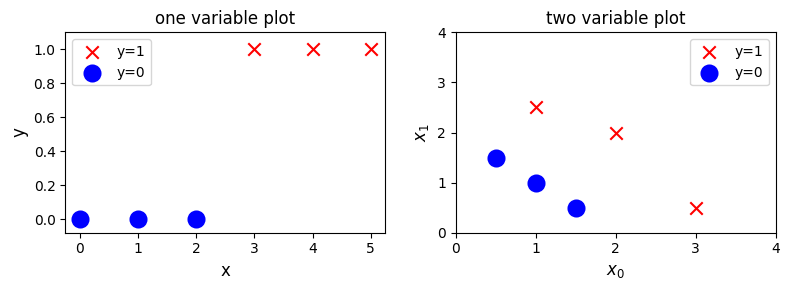

In [15]:
pos = y_train == 1
neg = y_train == 0
fig,ax = plt.subplots(1,2,figsize=(8,3))
ax[0].scatter(x_train[pos], y_train[pos], marker='x', s=80, c = 'red', label="y=1")
ax[0].scatter(x_train[neg], y_train[neg], marker='o', s=100, label="y=0", c='b', lw=3)
ax[0].set_ylim(-0.08,1.1)
ax[0].set_ylabel('y', fontsize=12)
ax[0].set_xlabel('x', fontsize=12)
ax[0].set_title('one variable plot')
ax[0].legend()

pos = y_train2 == 1
neg = y_train2 == 0
ax[1].scatter(X_train2[pos][:,0], X_train2[pos][:,1], marker='x', s=80, c = 'red', label="y=1")
ax[1].scatter(X_train2[neg][:,0], X_train2[neg][:,1], marker='o', s=100, label="y=0", c='b', lw=3)
ax[1].axis([0, 4, 0, 4])
ax[1].set_ylabel('$x_1$', fontsize=12)
ax[1].set_xlabel('$x_0$', fontsize=12)
ax[1].set_title('two variable plot')
ax[1].legend()
plt.tight_layout()
plt.show()

In [20]:
def costfunc(w: int, b: int, x: np.ndarray, y: np.ndarray) -> float:
    m = x.shape[0]
    sum = 0
    for i in range(m):
        sum += (w*x[i] + b - y[i])**2
    return sum//(2*m)

def compute_gradient(x, y, w, b): 
    m = x.shape[0]    
    dj_dw = 0
    dj_db = 0
    for i in range(m):  
        f_wb = w * x[i] + b 
        dj_db += f_wb - y[i] 
        dj_dw += (f_wb - y[i]) * x[i] 
    return dj_dw / m, dj_db / m

def gradient_descent(x, y, w_in, b_in, alpha, num_iters): 
    J_history = []
    b = b_in
    w = w_in
    
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(x, y, w , b)     
        b = b - alpha * dj_db                            
        w = w - alpha * dj_dw                            
        if i<100000:
            J_history.append(costfunc(w, b, x, y))
    return w, b, J_history



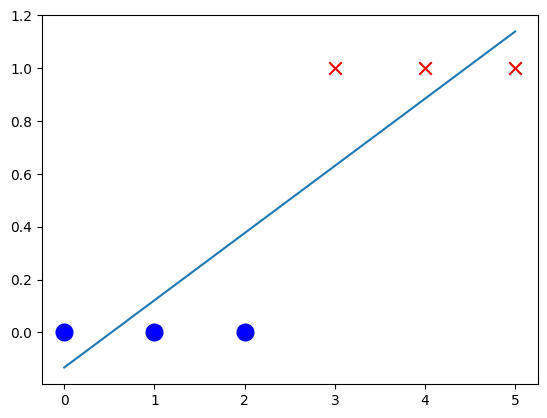

In [22]:
w, b, j = gradient_descent(x_train, y_train, 0, 0, 0.001, 10000)
plt.plot(x_train, w*x_train + b)
plt.scatter(x_train[pos], y_train[pos], marker='x', s=80, c = 'red', label="y=1")
plt.scatter(x_train[neg], y_train[neg], marker='o', s=100, label="y=0", c='b', lw=3)